# Tests lors de la création de preprocess data

In [1]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable


In [2]:
# Imports
from pathlib import Path
import pandas as pd
from sklearn.preprocessing import LabelEncoder

In [3]:
# 1. Data loading
data_file = "data/bronze/combined_data.csv"
df = pd.read_csv(data_file)

In [4]:
df.head(10)

,Unnamed: 0,family_id,sequence_name,family_accession,aligned_sequence,sequence
0,0,zf-Tim10_DDP,N1QB11_PSEFD/15-76,PF02953.15,..RMEKKQMKDFMNMYSNLVQRCFNDCV...........TD.F......,RMEKKQMKDFMNMYSNLVQRCFNDCVTDFTSKSLQSKEEGCVMRCV...
1,1,DNA_primase_S,A8XA78_CAEBR/105-345,PF01896.19,FDID..LTDYDNIRNCCKEATVCPKCWKFMVLAVKILDFLLDDMFG...,FDIDLTDYDNIRNCCKEATVCPKCWKFMVLAVKILDFLLDDMFGFN...
2,2,Col_cuticle_N,A8XBM5_CAEBR/9-56,PF01484.17,ASAAILSGATIVGCLFFAAQIFNEVNSLYDDVMVDMDAFKVKSNIA...,ASAAILSGATIVGCLFFAAQIFNEVNSLYDDVMVDMDAFKVKSNIAWD
3,3,GST_C_3,W4XBU3_STRPU/120-207,PF14497.6,KD.................................KLKESLPKTVN...,KDKLKESLPKTVNPILLKFLEKALEDNPNGNGYFVGQDATMVEFVY...
4,4,Ada_Zn_binding,E8U5K2_DEIML/9-73,PF02805.16,DRWQAVVQRE...AAQ.DG...LFLYAVRTTGIYCRPSCPSRRPR....,DRWQAVVQREAAQDGLFLYAVRTTGIYCRPSCPSRRPRRENVTFFE...
5,5,Flg_new,M4RB64_9BIFI/796-861,PF09479.10,YTLSFD.A...N..G...G..S......VS...PGS...K.....S...,YTLSFDANGGSVSPGSKSVTYGGAYGQLPTPSRKGYTFQGWYTAKN...
6,6,DUF4360,A8NVM1_COPC7/24-193,PF14273.6,AELKLK.SVGAIGTGCPPGTVVGR..VNKDDS......LSLF.FAK...,AELKLKSVGAIGTGCPPGTVVGRVNKDDSLSLFFAKFRADAGPTFD...
7,7,DUF1949,A0PZT9_CLONN/138-193,PF09186.11,INIDYDLLGKVQYVCG...Q.NL.WHMEDTEYTDK..VSILILTES...,INIDYDLLGKVQYVCGQNLWHMEDTEYTDKVSILILTESSNCENIK...
8,8,HSF_DNA-bind,I2GV49_TETBL/163-265,PF00447.17,FVNKLWNM...L.....N..........DP...................,FVNKLWNMLNDPINQDMIRWSDDGKSFLVVNREKFVHHVLPNYFKH...
9,9,MacB_PCD,A6X4W0_OCHA4/276-497,PF12704.7,TFL.TMLGIIIG..TASVVCVV.ALGQGSQRQILER..IS.....D...,TFLTMLGIIIGTASVVCVVALGQGSQRQILERISDLGTNTLYISPG...


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1339083 entries, 0 to 1339082
Data columns (total 6 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   Unnamed: 0        1339083 non-null  int64 
 1   family_id         1339083 non-null  object
 2   sequence_name     1339083 non-null  object
 3   family_accession  1339083 non-null  object
 4   aligned_sequence  1339083 non-null  object
 5   sequence          1339083 non-null  object
dtypes: int64(1), object(5)
memory usage: 61.3+ MB


In [6]:
# 2. Remove null values
print("nb rows before drop: ", df.shape[0])
df = df.dropna(axis=0, how='any')
print("nb rows after drop: ", df.shape[0])
print("nb of null elements: ", df.isnull().sum().sum())

nb rows before drop:  1339083
nb rows after drop:  1339083
nb of null elements:  0


In [7]:
#3. Encode family_accession column with LabelEncoder
le = LabelEncoder()
df["family_encoded"] = le.fit_transform(df["family_accession"])
df.head(10)

,Unnamed: 0,family_id,sequence_name,family_accession,aligned_sequence,sequence,family_encoded
0,0,zf-Tim10_DDP,N1QB11_PSEFD/15-76,PF02953.15,..RMEKKQMKDFMNMYSNLVQRCFNDCV...........TD.F......,RMEKKQMKDFMNMYSNLVQRCFNDCVTDFTSKSLQSKEEGCVMRCV...,2718
1,1,DNA_primase_S,A8XA78_CAEBR/105-345,PF01896.19,FDID..LTDYDNIRNCCKEATVCPKCWKFMVLAVKILDFLLDDMFG...,FDIDLTDYDNIRNCCKEATVCPKCWKFMVLAVKILDFLLDDMFGFN...,1780
2,2,Col_cuticle_N,A8XBM5_CAEBR/9-56,PF01484.17,ASAAILSGATIVGCLFFAAQIFNEVNSLYDDVMVDMDAFKVKSNIA...,ASAAILSGATIVGCLFFAAQIFNEVNSLYDDVMVDMDAFKVKSNIAWD,1406
3,3,GST_C_3,W4XBU3_STRPU/120-207,PF14497.6,KD.................................KLKESLPKTVN...,KDKLKESLPKTVNPILLKFLEKALEDNPNGNGYFVGQDATMVEFVY...,13609
4,4,Ada_Zn_binding,E8U5K2_DEIML/9-73,PF02805.16,DRWQAVVQRE...AAQ.DG...LFLYAVRTTGIYCRPSCPSRRPR....,DRWQAVVQREAAQDGLFLYAVRTTGIYCRPSCPSRRPRRENVTFFE...,2590
5,5,Flg_new,M4RB64_9BIFI/796-861,PF09479.10,YTLSFD.A...N..G...G..S......VS...PGS...K.....S...,YTLSFDANGGSVSPGSKSVTYGGAYGQLPTPSRKGYTFQGWYTAKN...,8789
6,6,DUF4360,A8NVM1_COPC7/24-193,PF14273.6,AELKLK.SVGAIGTGCPPGTVVGR..VNKDDS......LSLF.FAK...,AELKLKSVGAIGTGCPPGTVVGRVNKDDSLSLFFAKFRADAGPTFD...,13390
7,7,DUF1949,A0PZT9_CLONN/138-193,PF09186.11,INIDYDLLGKVQYVCG...Q.NL.WHMEDTEYTDK..VSILILTES...,INIDYDLLGKVQYVCGQNLWHMEDTEYTDKVSILILTESSNCENIK...,8509
8,8,HSF_DNA-bind,I2GV49_TETBL/163-265,PF00447.17,FVNKLWNM...L.....N..........DP...................,FVNKLWNMLNDPINQDMIRWSDDGKSFLVVNREKFVHHVLPNYFKH...,430
9,9,MacB_PCD,A6X4W0_OCHA4/276-497,PF12704.7,TFL.TMLGIIIG..TASVVCVV.ALGQGSQRQILER..IS.....D...,TFLTMLGIIIGTASVVCVVALGQGSQRQILERISDLGTNTLYISPG...,11875


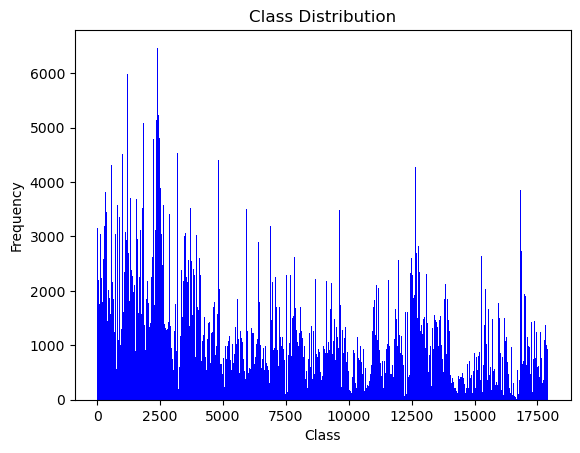

In [8]:
#4. Distribution analysis
import matplotlib.pyplot as plt
plt.hist(df["family_encoded"],bins=1000,color='blue')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# Division des classes entre rare et common 
family_count = df['family_encoded'].value_counts()
rare_families = family_count[family_count < 10].index
df_rare = df[df['family_encoded'].isin(rare_families)]
df_common = df[~df['family_encoded'].isin(rare_families)]

print("Nombre d'échantillons rare: ", df_rare.shape[0])
print("Nombre d'échantillons communes: ", df_common.shape[0])

Nombre d'échantillons rare:  21791
Nombre d'échantillons communes:  1317292


In [19]:
# Split Stratify sur common
from sklearn.model_selection import train_test_split
X = df_common['sequence']
y = df_common['family_encoded']

# Premier split = 70% train et 30% test
Xcommon_train, X_temp, y_train_common, y_temp = train_test_split(
    X, 
    y, 
    test_size=0.30, 
    random_state=42, 
    stratify=y)

# Deuxième split = 15% test et 15% validation
X_test, X_val, y_test, y_val = train_test_split(
    X_temp, 
    y_temp, 
    test_size=0.5, 
    random_state=42, 
    stratify=y_temp)

# Fusion rare et common
X_rare = df_rare['sequence']
y_rare = df_rare['family_encoded']
X_train = pd.concat([Xcommon_train, X_rare], ignore_index=True)
y_train = pd.concat([y_train_common, y_rare], ignore_index=True)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")
print(f"Familles dans train: {y_train.nunique()}")
print(f"Familles dans val: {y_val.nunique()}")
print(f"Familles dans test: {y_test.nunique()}")

Train: 943895, Val: 197594, Test: 197594
Familles dans train: 17929
Familles dans val: 13071
Familles dans test: 13071


In [20]:
# Sauvegarde de train, val et test dans des csv

def save_splits(X_train, y_train, X_val, y_val, X_test, y_test, output_dir):

    # Créer le dossier si nécessaire
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # Créer les DataFrames
    train_df = pd.DataFrame({
        'sequence': X_train.values,
        'family_encoded': y_train.values
    })
    
    val_df = pd.DataFrame({
        'sequence': X_val.values,
        'family_encoded': y_val.values
    })
    
    test_df = pd.DataFrame({
        'sequence': X_test.values,
        'family_encoded': y_test.values
    })
    
    # Sauvegarder
    train_df.to_csv(output_dir / 'train.csv', index=False)
    val_df.to_csv(output_dir / 'val.csv', index=False)
    test_df.to_csv(output_dir / 'test.csv', index=False)

save_splits(X_train, y_train, X_val, y_val, X_test, y_test, output_dir='data/silver')